## **1) Data Preprocessing**
- Import packages and dataset
- Handling Missing Values
- Handling Duplicates
- Checking and Fixing the datatypes
- Understand the dataset

**1.1 Import Packages and dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings as wn

wn.filterwarnings("ignore")
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format", "{:.4f}".format)
# Create a Dataframe
data = pd.read_csv("data/churn-data.csv")
# Shape of the dataset
print(data.shape)

(7043, 21)


**1.2 Handling Missing Values**

In [2]:
## Checking missing values 
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

- There are **no null values** in the dataset.

**1.3 Handling Duplicates**

In [3]:
data.duplicated().sum()

np.int64(0)

- **No duplicates** in the dataset.

**1.4 Checking and Fixing Datatypes**

In [4]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes


In [5]:
data.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [6]:
# Converting TotalCharges str to float type
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

In [7]:
data.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [8]:
data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

- There are some null values in **TotalCharges** after converting it to float type.
- Drop the missing values.

In [9]:
data = data.dropna()

In [10]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**1.5 Dropping the customerID column which is not important**

In [11]:
data = data.drop("customerID", axis=1)

In [12]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.8500,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5000,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.1500,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.7500,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.6500,Yes


In [13]:
# Transforming columns with having category like "No phone Service or No internet Service" to "No"
columns_to_transform = ["MultipleLines","OnlineSecurity","OnlineBackup","DeviceProtection",
                        "TechSupport","StreamingTV","StreamingMovies"]

for col in columns_to_transform :
    data[col] = data[col].str.replace("No phone service", "No").str.replace("No internet service", "No")

In [14]:
for col in columns_to_transform:
    print(data[col].value_counts())

MultipleLines
No     4065
Yes    2967
Name: count, dtype: int64
OnlineSecurity
No     5017
Yes    2015
Name: count, dtype: int64
OnlineBackup
No     4607
Yes    2425
Name: count, dtype: int64
DeviceProtection
No     4614
Yes    2418
Name: count, dtype: int64
TechSupport
No     4992
Yes    2040
Name: count, dtype: int64
StreamingTV
No     4329
Yes    2703
Name: count, dtype: int64
StreamingMovies
No     4301
Yes    2731
Name: count, dtype: int64


**1.6 SeniorCitizen: Decode Integer to Label**

In [15]:
data["SeniorCitizen"] = data["SeniorCitizen"].map({0:"No", 1:"Yes"})
print(data["SeniorCitizen"].value_counts())
print(data.dtypes)

SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64
gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


## **2) Feature Engineering**

**2.1 Tenure Binning**

In [16]:
bins = [0, 12, 24, 48, 72]
labels = ["New (0-12m)", "Growing (13-24m)", "Established (25-48m)", "Loyal (49-72m)"]
data["tenure_group"] = pd.cut(data["tenure"], bins=bins, labels=labels, include_lowest=True)

print("Tenure Group Distribution: ")
print(data["tenure_group"].value_counts().sort_index())

# Churn rate by tenure group
churn_by_tenure = data.groupby("tenure_group")["Churn"].apply(lambda x: (x == "Yes").mean() * 100).round(4)
print("\nChurn rate (%) by tenure")
print(churn_by_tenure)

data.groupby("tenure_group")["Churn"].apply(lambda x: (x=="Yes").mean())

Tenure Group Distribution: 
tenure_group
New (0-12m)             2175
Growing (13-24m)        1024
Established (25-48m)    1594
Loyal (49-72m)          2239
Name: count, dtype: int64

Churn rate (%) by tenure
tenure_group
New (0-12m)            47.6782
Growing (13-24m)       28.7109
Established (25-48m)   20.3890
Loyal (49-72m)          9.5132
Name: Churn, dtype: float64


tenure_group
New (0-12m)            0.4768
Growing (13-24m)       0.2871
Established (25-48m)   0.2039
Loyal (49-72m)         0.0951
Name: Churn, dtype: float64

**2.2 Average Monthly Charges and Charge Delta**

In [17]:
# average_monthly_charges = total_charges / tenure
data["avg_monthly_charges"] = data["TotalCharges"] / data["tenure"]

# charge_delta : how much current bill deviates from the lifetime average 
data["charge_delta"] = data["MonthlyCharges"] - data["avg_monthly_charges"]

print(data[["tenure", "MonthlyCharges", "TotalCharges", "avg_monthly_charges", "charge_delta"]].head(10))

   tenure  MonthlyCharges  TotalCharges  avg_monthly_charges  charge_delta
0       1         29.8500       29.8500              29.8500        0.0000
1      34         56.9500     1889.5000              55.5735        1.3765
2       2         53.8500      108.1500              54.0750       -0.2250
3      45         42.3000     1840.7500              40.9056        1.3944
4       2         70.7000      151.6500              75.8250       -5.1250
5       8         99.6500      820.5000             102.5625       -2.9125
6      22         89.1000     1949.4000              88.6091        0.4909
7      10         29.7500      301.9000              30.1900       -0.4400
8      28        104.8000     3046.0500             108.7875       -3.9875
9      62         56.1500     3487.9500              56.2573       -0.1073


**2.3 Service Count**

Service Count by distribution:
num_services
0    2213
3    1117
2    1033
1     966
4     850
5     569
6     284
Name: count, dtype: int64


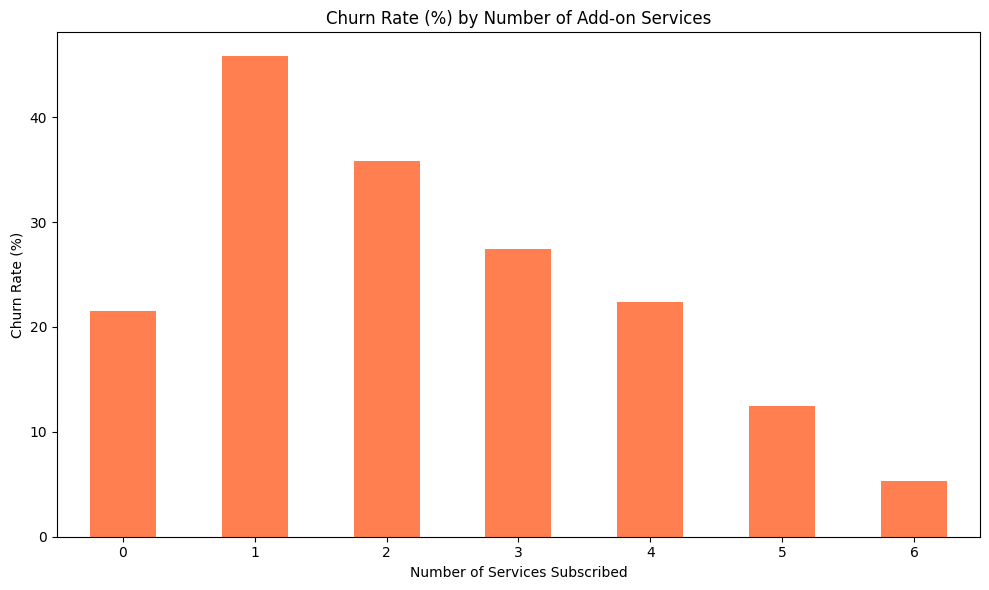

In [18]:
addon_services = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", 
                  "TechSupport", "StreamingTV", "StreamingMovies"]
data["num_services"] = data[addon_services].apply(lambda row: (row == "Yes").sum(), axis=1)
print("Service Count by distribution:")
print(data["num_services"].value_counts())

churn_by_services = data.groupby("num_services")["Churn"].apply(lambda x: (x == "Yes").mean() * 100).round(1)
fig,ax = plt.subplots(figsize=(10,6))
churn_by_services.plot(kind="bar", color="coral", ax=ax)
ax.set_title("Churn Rate (%) by Number of Add-on Services")
ax.set_xlabel("Number of Services Subscribed")
ax.set_ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**2.4 Contract Risk Score**

In [19]:
# month-to-month contract customer have higher risk of churn
# one-year contract customer have medium risk and two-year have low risk of churn
data["contract_risk"] = data["Contract"].map({"Month-to-month": 3, "One year": 2, "Two year": 1})

churn_by_contract = data.groupby("Contract")["Churn"].apply(lambda x: (x == "Yes").mean() * 100).round(4)
print("Churn rate (%) by Contract")
print(churn_by_contract)

Churn rate (%) by Contract
Contract
Month-to-month   42.7097
One year         11.2772
Two year          2.8487
Name: Churn, dtype: float64


**2.5 Paperless billing and Electronic Payment Flag**

In [20]:
# Electronic check and paperless billing combined correlates with churn
data["is_electronic_check"] = (data["PaymentMethod"] == "Electronic check").astype(int)
data["is_auto_payment"] = data["PaymentMethod"].str.contains("automatic", case=False).astype(int)

# high friction billing = non autopayment and paperless have higher risk of churn
data["high_friction_billing"] = (
    (data["is_auto_payment"] == 0) & (data["PaperlessBilling"] == "Yes")
).astype(int)

print(data[["PaymentMethod", "PaperlessBilling", "is_electronic_check", "is_auto_payment", "high_friction_billing"]].head(10))

               PaymentMethod PaperlessBilling  is_electronic_check  \
0           Electronic check              Yes                    1   
1               Mailed check               No                    0   
2               Mailed check              Yes                    0   
3  Bank transfer (automatic)               No                    0   
4           Electronic check              Yes                    1   
5           Electronic check              Yes                    1   
6    Credit card (automatic)              Yes                    0   
7               Mailed check               No                    0   
8           Electronic check              Yes                    1   
9  Bank transfer (automatic)               No                    0   

   is_auto_payment  high_friction_billing  
0                0                      1  
1                0                      0  
2                0                      1  
3                1                      0  
4        

**2.6 Vulnerability Score**

In [21]:
# SeniorCitizen with no Partners and no Dependents have higher risk of churn
data["vulnerability_score"] = (
    (data["SeniorCitizen"] == "Yes").astype(int) +
    (data["Partner"] == "No").astype(int) +
    (data["Dependents"] == "No").astype(int)
)

churn_by_vulnerability = data.groupby("vulnerability_score")["Churn"].apply(lambda x: (x == "Yes").mean() * 100).round(4)
print("Churn rate (%) by Vulnearbility Score")
print(churn_by_vulnerability)

Churn rate (%) by Vulnearbility Score
vulnerability_score
0   13.8202
1   21.1021
2   31.9242
3   49.1979
Name: Churn, dtype: float64


**2.7 Feature Correlation with Target**

In [22]:
# Point Biserial Correlation between numerical features and binary target churn
from scipy.stats import pointbiserialr

churn_binary = (data["Churn"] == "Yes").astype(int)

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges",
                "avg_monthly_charges", "charge_delta",
                "num_services", "contract_risk",
                "is_electronic_check", "is_auto_payment",
                "high_friction_billing", "vulnerability_score"]

corr_results = []
for col in numeric_cols :
    corr, p_value = pointbiserialr(data[col], churn_binary)
    corr_results.append({
        "Feature": col, 
        "Correlation" : corr,
        "P-value" : p_value
    })

corr_df = pd.DataFrame(corr_results).sort_values(by="Correlation", key=abs, ascending = False)
print("Point Biserial Correlation with Churn")
print(corr_df)

Point Biserial Correlation with Churn
                  Feature  Correlation  P-value
6           contract_risk       0.3961   0.0000
0                  tenure      -0.3540   0.0000
7     is_electronic_check       0.3015   0.0000
9   high_friction_billing       0.2777   0.0000
10    vulnerability_score       0.2203   0.0000
8         is_auto_payment      -0.2104   0.0000
2            TotalCharges      -0.1995   0.0000
1          MonthlyCharges       0.1929   0.0000
3     avg_monthly_charges       0.1920   0.0000
5            num_services      -0.0879   0.0000
4            charge_delta       0.0022   0.8563


In [23]:
# Chi-Squared Test : statistical significance between categorical features vs churn
from scipy.stats import chi2_contingency
cat_cols_to_test = ["gender", "SeniorCitizen", "Partner", "Dependents",
                    "PhoneService", "MultipleLines", "InternetService",
                    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
                    "TechSupport", "StreamingTV", "StreamingMovies",
                    "Contract", "PaperlessBilling", "PaymentMethod", "tenure_group"]

chi2_results = []
for col in cat_cols_to_test :
    ct = pd.crosstab(data[col], data["Churn"])
    chi2, p_value, dof, expected = chi2_contingency(ct)
    decision = "Keep" if p_value < 0.05 else "Consider Dropping"

    chi2_results.append({
        "Feature" : col, 
        "Chi2" : chi2,
        "P-value" : p_value,
        "Decision" : decision
    })

chi2_df = pd.DataFrame(chi2_results).sort_values("P-value", ascending=False)
print("Chi-Squared Test - Categorical Test vs Churn")
print(chi2_df)

Chi-Squared Test - Categorical Test vs Churn
             Feature      Chi2  P-value           Decision
0             gender    0.4755   0.4905  Consider Dropping
4       PhoneService    0.8737   0.3499  Consider Dropping
5      MultipleLines   11.0869   0.0009               Keep
12   StreamingMovies   25.7641   0.0000               Keep
11       StreamingTV   27.8419   0.0000               Keep
9   DeviceProtection   30.4957   0.0000               Keep
8       OnlineBackup   47.2467   0.0000               Keep
2            Partner  157.5032   0.0000               Keep
1      SeniorCitizen  158.4408   0.0000               Keep
3         Dependents  186.3216   0.0000               Keep
10       TechSupport  189.9668   0.0000               Keep
7     OnlineSecurity  205.4158   0.0000               Keep
14  PaperlessBilling  256.8749   0.0000               Keep
15     PaymentMethod  645.4299   0.0000               Keep
6    InternetService  728.6956   0.0000               Keep
16      ten

## **3) Encoding and Scaling**

**3.1 Splitting features into Input and Output**

In [24]:
X = data.drop("Churn", axis=1)
y = data["Churn"].map({"No": 0, "Yes": 1})

# Feature Cateogries
# Binary columns - Yes/No
binary_cols = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", 
               "MultipleLines","OnlineSecurity", "OnlineBackup", "DeviceProtection", 
               "TechSupport", "StreamingTV", "StreamingMovies", "PaperlessBilling"]

# Ordinal columns - where categories have order 
ordinal_cols = ["Contract", "tenure_group"]
contract_order = ["Month-to-month", "One year", "Two year"]
tenure_order = ["New (0-12m)", "Growing (13-24m)", "Established (25-48m)", "Loyal (49-72m)"]

# nominal cols - where categories have no order
nominal_cols = ["InternetService", "PaymentMethod"]

# numerical features to scale 
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", 
                "avg_monthly_charges", "charge_delta"]

# already numeric integers - pass through without scaling
pass_through_cols = ["num_services", "contract_risk", "is_electronic_check",
                     "is_auto_payement", "high_friction_bill", "vulnerability_score"]

print(f"Binary Columns : {binary_cols}")
print(f"Ordinal Columns : {ordinal_cols}")
print(f"Nominal Columns : {nominal_cols}")
print(f"Numeric Columns : {numeric_cols}")
print(f"Passthrough Columns : {pass_through_cols}")

Binary Columns : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']
Ordinal Columns : ['Contract', 'tenure_group']
Nominal Columns : ['InternetService', 'PaymentMethod']
Numeric Columns : ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_charges', 'charge_delta']
Passthrough Columns : ['num_services', 'contract_risk', 'is_electronic_check', 'is_auto_payement', 'high_friction_bill', 'vulnerability_score']


**3.2 Binary Encoding**

In [25]:
binary_map = {"Yes": 1, "No": 0, "Female": 1, "Male": 0}
for col in binary_cols :
    X[col] = X[col].map(binary_map)

print("Binary Encoding Completed")
print("Sample")
X[binary_cols].head(5)

Binary Encoding Completed
Sample


,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling
0,1,0,1,0,0,0,0,1,0,0,0,0,1
1,0,0,0,0,1,0,1,0,1,0,0,0,0
2,0,0,0,0,1,0,1,1,0,0,0,0,1
3,0,0,0,0,0,0,1,0,1,1,0,0,0
4,1,0,0,0,1,0,0,0,0,0,0,0,1


**3.3 Ordinal Encoding**

In [26]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder(
    categories=[contract_order, tenure_order],
    handle_unknown="use_encoded_value",
    unknown_value= -1
)

X[ordinal_cols] = ordinal_encoder.fit_transform(X[ordinal_cols].astype(str))
print("Ordinal Encoding Completed: ")
print(X[ordinal_cols].value_counts().head(10))

Ordinal Encoding Completed: 
Contract  tenure_group
0.0000    0.0000          1994
2.0000    3.0000          1263
0.0000    2.0000           802
          1.0000           737
1.0000    3.0000           634
          2.0000           518
0.0000    3.0000           342
2.0000    2.0000           274
1.0000    1.0000           197
          0.0000           123
Name: count, dtype: int64


**3.4 One Hot Encoding(Nominal Encoding)**

In [27]:
# InternetService has 
X = pd.get_dummies(X, columns = nominal_cols, dtype=int)

ohe_cols = [c for c in X.columns if "InternetService" in c or "PaymentMethod" in c]
print(ohe_cols)
print(f"\nDataFrame shape after OHE: {X.shape}")
X.head(3)

['InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

DataFrame shape after OHE: (7032, 33)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,tenure_group,avg_monthly_charges,charge_delta,num_services,contract_risk,is_electronic_check,is_auto_payment,high_friction_billing,vulnerability_score,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,0,0,0,0.0000,1,29.8500,29.8500,0.0000,29.8500,0.0000,1,3,1,0,1,1,1,0,0,0,0,1,0
1,0,0,0,0,34,1,0,1,0,1,0,0,0,1.0000,0,56.9500,1889.5000,2.0000,55.5735,1.3765,2,2,0,0,0,2,1,0,0,0,0,0,1
2,0,0,0,0,2,1,0,1,1,0,0,0,0,0.0000,1,53.8500,108.1500,0.0000,54.0750,-0.2250,2,3,0,0,1,2,1,0,0,0,0,0,1


**3.5 Standard Scaling**

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print("Scaling Columns completed")
print(X[numeric_cols].describe())

Scaling Columns completed
         tenure  MonthlyCharges  TotalCharges  avg_monthly_charges  \
count 7032.0000       7032.0000     7032.0000            7032.0000   
mean    -0.0000          0.0000       -0.0000               0.0000   
std      1.0001          1.0001        1.0001               1.0001   
min     -1.2802         -1.5473       -0.9991              -1.6905   
25%     -0.9543         -0.9710       -0.8302              -0.9482   
50%     -0.1394          0.1845       -0.3908               0.1847   
75%      0.9199          0.8331        0.6668               0.8409   
max      1.6126          1.7934        2.8243               1.8752   

       charge_delta  
count     7032.0000  
mean         0.0000  
std          1.0001  
min         -7.2244  
25%         -0.4430  
50%          0.0005  
75%          0.4392  
max          7.3113  


**3.6 Handling Class Imbalance**

Text(0.5, 1.0, 'After SMOTE')

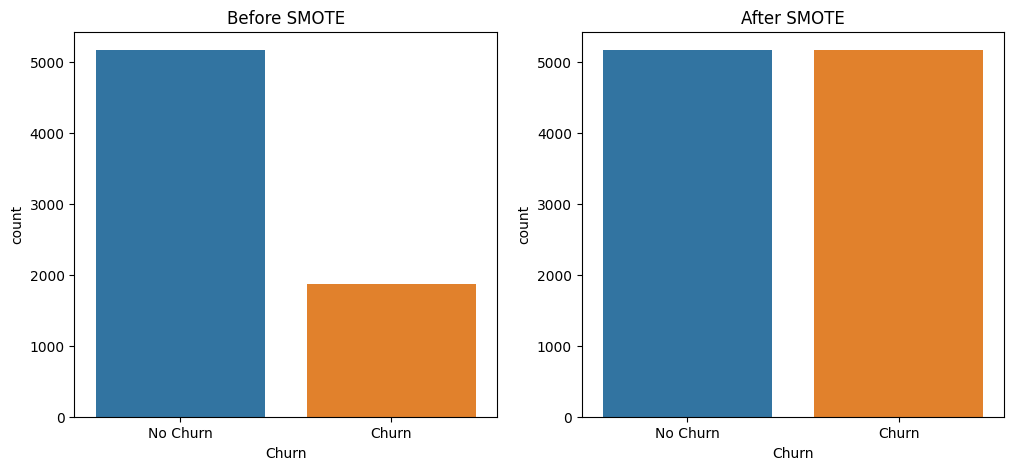

In [29]:
# Upsampling the 
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy="minority", random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
sns.countplot(x= pd.Series(y).map({0: "No Churn", 1: "Churn"}), palette="tab10")
plt.title("Before SMOTE")
plt.subplot(1,2,2)
sns.countplot(x= pd.Series(y_resampled).map({0: "No Churn", 1: "Churn"}), palette="tab10")
plt.title("After SMOTE")

## **4) Model Training**

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, \
                            precision_score, recall_score, f1_score, roc_auc_score 

In [31]:
def evaluate_models(true, pred) :
    accuracy = accuracy_score(true, pred)
    report = classification_report(true, pred)
    matrix = confusion_matrix(true, pred)
    precision = precision_score(true, pred)
    recall = recall_score(true, pred)
    f1 = f1_score(true, pred)
    roc_score = roc_auc_score(true, pred)

    return accuracy, report, matrix, precision, recall, f1, roc_score


In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_resampled,y_resampled,test_size=0.3,random_state=42)
X_train.shape, X_test.shape

((7228, 33), (3098, 33))

In [33]:
models = {
    "Logistic Regression" : LogisticRegression(),
    "DecisionTreeClassifier" : DecisionTreeClassifier(),
    "KNeighborsClassifier" : KNeighborsClassifier(),
    "AdaBoost" : AdaBoostClassifier(),
    "Gradient Boost" : GradientBoostingClassifier(),
    "Random Forest" : RandomForestClassifier()
}
model_list = []
acc_list = []
test_roc_score = []
for i in range(len(models)):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc, train_report, train_matrix, train_precision, train_recall, train_f1, train_roc = evaluate_models(y_train, y_train_pred)
    test_acc, test_report, test_matrix, test_precision, test_recall, test_f1, test_roc = evaluate_models(y_test, y_test_pred)
    
    print(list(models.keys())[i])
    print("Model Performance for Training Set")
    print(f"Accuracy Score: {train_acc:.4f}")
    print(f"Classification Report: \n{train_report}")
    print(f"Confusion Matrix: \n{train_matrix}")
    print(f"Precision Score: {train_precision:.4f}")
    print(f"Recall Score: {train_recall:.4f}")
    print(f"F1 Score: {train_f1:.4f}")
    print(f"ROC Score: {train_roc:.4f}")

    print("--------------------------------------------")
    print("Model Performance for Test Set")
    print(f"Accuracy Score: {test_acc:.4f}")
    print(f"Classification Report: \n {test_report}")
    print(f"Confusion Matrix: \n{test_matrix}")
    print(f"Precision Score: {test_precision:.4f}")
    print(f"Recall Score: {test_recall:.4f}")
    print(f"F1 Score: {test_f1:.4f}")
    print(f"ROC Score: {test_roc:.4f}")

    print("="*50)
    print("\n")
    model_list.append(list(models.keys())[i])
    acc_list.append(test_acc)
    test_roc_score.append(test_roc)


Logistic Regression
Model Performance for Training Set
Accuracy Score: 0.8280
Classification Report: 
              precision    recall  f1-score   support

           0       0.84      0.81      0.82      3600
           1       0.82      0.84      0.83      3628

    accuracy                           0.83      7228
   macro avg       0.83      0.83      0.83      7228
weighted avg       0.83      0.83      0.83      7228

Confusion Matrix: 
[[2929  671]
 [ 572 3056]]
Precision Score: 0.8200
Recall Score: 0.8423
F1 Score: 0.8310
ROC Score: 0.8280
--------------------------------------------
Model Performance for Test Set
Accuracy Score: 0.8305
Classification Report: 
               precision    recall  f1-score   support

           0       0.84      0.82      0.83      1563
           1       0.82      0.84      0.83      1535

    accuracy                           0.83      3098
   macro avg       0.83      0.83      0.83      3098
weighted avg       0.83      0.83      0.83      

In [34]:
print(model_list)
print(acc_list)

model_df = pd.DataFrame({"Model": model_list, "Accuracy": acc_list, "ROC": test_roc_score}).sort_values("Accuracy", ascending=False)
model_df

['Logistic Regression', 'DecisionTreeClassifier', 'KNeighborsClassifier', 'AdaBoost', 'Gradient Boost', 'Random Forest']
[0.8305358295674629, 0.7824402840542285, 0.8102001291155584, 0.7830858618463525, 0.8173014848289218, 0.8476436410587476]


,Model,Accuracy,ROC
5,Random Forest,0.8476,0.8480
0,Logistic Regression,0.8305,0.8307
4,Gradient Boost,0.8173,0.8177
2,KNeighborsClassifier,0.8102,0.8111
3,AdaBoost,0.7831,0.7836
1,DecisionTreeClassifier,0.7824,0.7825
